In [18]:
library(tidyverse)
library(vars)
library(svars)
library(stargazer)
library(xtable)

In [6]:
inflation_cob= read_csv("data/Inflation/colombia.csv", col_types = cols(
  date = col_date(format="%b-%y"),
  cpi_food = col_double(),
  cpi_core = col_double(),
  cpi_fuel = col_double(),
  cpi = col_double()
))

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [7]:
#computing inflation figure 
inflation_cob = inflation_cob %>% 
                    arrange(date) %>%
                        mutate(inflation= (cpi/lag(cpi, 1) - 1)*100*12)


inflation_cob = inflation_cob %>% 
                    arrange(date) %>%
                        mutate(inflation_food= (cpi_food/lag(cpi_food, 1) - 1)*100*12)


inflation_cob = inflation_cob %>% 
                    arrange(date) %>%
                        mutate(inflation_core= (cpi_core/lag(cpi_core, 1) - 1)*100*12)


inflation_cob = inflation_cob %>% 
                    arrange(date) %>%
                        mutate(inflation_fuel= (cpi_fuel/lag(cpi_fuel, 1) - 1)*100*12)



In [8]:
#reading expectation data, india
expec_cob=read_csv("data/expectations/colombia.csv", col_types=cols(
    date=col_date(format="%b-%y"),
    expec= col_double()
    )
)

In [11]:
data_cob=left_join(inflation_cob, expec_cob, by="date")
data_cob=data_cob %>% filter(!is.na(inflation), !is.na(inflation_food))

# data_ind=tail(data_ind, 78)
# data_ind=head(data_ind, 70)
data_cob = data_cob %>% filter(!is.na(expec))

data_cob = data_cob %>% dplyr::select(inflation_food, expec, inflation_core)

In [12]:
library(vars)
library(svars)

In [15]:
var_model = VAR(data_cob, p = 2, type = "const")

In [16]:
A_matrix <- matrix(NA, 3, 3)
colnames(A_matrix) <- rownames(A_matrix) <- c("food", "expectations", "core")

# Imposing zero restrictions (short-run)
A_matrix[1, 2:3] <- 0  # food doesn't respond to others contemporaneously
A_matrix[2, 3]   <- 0  # expectations doesn't respond to core contemporaneously
A_matrix[3, 1:2] <- 0  # core doesn't respond to food or expectations contemporaneously

# Estimate the SVAR with short-run restrictions
# svar_model <- id.short(var_model, restriction_matrix = A_matrix)
svar_model <- SVAR(var_model, estmethod = "direct", Amat = A_matrix)

# Summary
summary(svar_model)


SVAR Estimation Results:

Call:
SVAR(x = var_model, estmethod = "direct", Amat = A_matrix)

Type: A-model 
Sample size: 257 
Log Likelihood: -1400.04 
Method: direct 
Number of iterations: 439 
Convergence code: 0 

LR overidentification test:

	LR overidentification

data:  data_cob
Chi^2 = 177, df = 2, p-value <2e-16


Estimated A matrix:
               inflation_food expec inflation_core
inflation_food        0.11177 0.000         0.0000
expec                -0.05528 6.853         0.0000
inflation_core        0.00000 0.000         0.3969

Estimated B matrix:
               inflation_food expec inflation_core
inflation_food              1     0              0
expec                       0     1              0
inflation_core              0     0              1

Covariance matrix of reduced form residuals (*100):
               inflation_food expec inflation_core
inflation_food        8004.72 64.57            0.0
expec                   64.57  2.65            0.0
inflation_core       

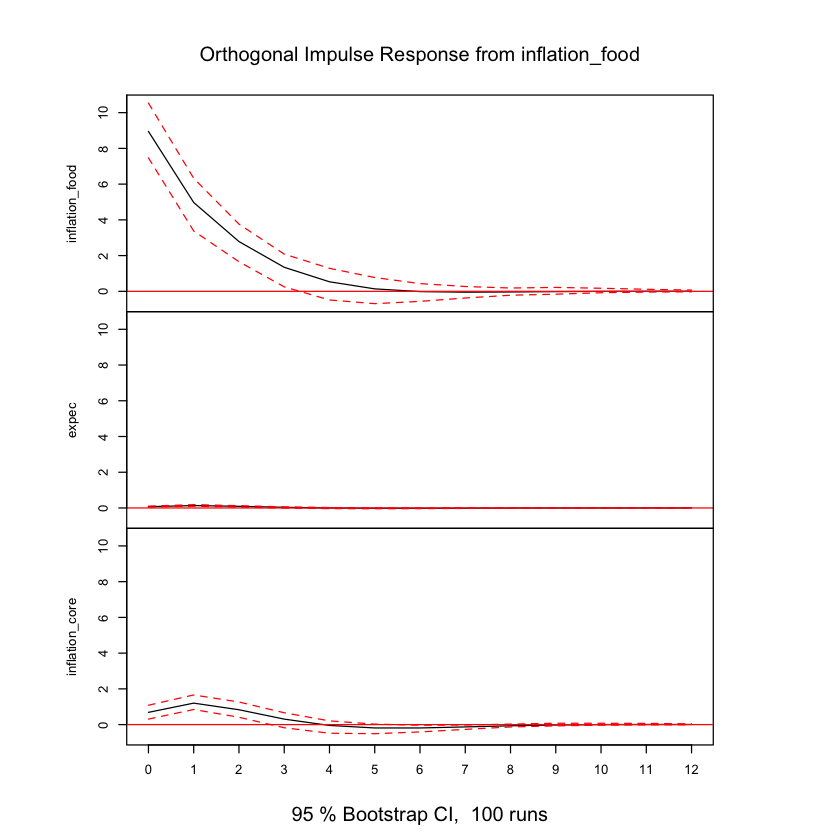

In [17]:

par(bg = "white")
irf_var <- irf(var_model, impulse = c("inflation_food"), response = c("inflation_food","expec","inflation_core"), n.ahead = 12, boot = TRUE)
plot(irf_var)

In [19]:
stargazer(svar_model$A, type = "latex", title = "SVAR Coefficient Estimates")


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: Fri, May 09, 2025 - 17:04:36
\begin{table}[!htbp] \centering 
  \caption{SVAR Coefficient Estimates} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}} cccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
 & inflation\_food & expec & inflation\_core \\ 
\hline \\[-1.8ex] 
inflation\_food & $0.112$ & $0$ & $0$ \\ 
expec & $$-$0.055$ & $6.853$ & $0$ \\ 
inflation\_core & $0$ & $0$ & $0.397$ \\ 
\hline \\[-1.8ex] 
\end{tabular} 
\end{table} 
